# Test instances

In [1]:
import numpy as np
from pprint import pprint
import pyomo.environ as pyo

from scipy.integrate import solve_ivp
from phdtools.integrate import euler

from phdtools.optimization import (
    EPSILON,
    NOMINAL_THERMAL_POWER_SI,
    GROSS_CALORIFIC_VALUE_METHANE_SI,
)

from phdtools.optimization.pyomo import (
    pyomo_print_constraint_residuals,
    reformer_block_rule,
    shift_block_rule,
    fuel_cell_block_rule,
    warmstart_reformer,
    warmstart_shift,
)

from phdtools.optimization.data_preparation import (
    create_reformer_data_dict,
    create_shift_data_dict,
    create_fuel_cell_data_dict,
)

from phdtools.plots.optimization.postprocessing import (
    plot_optimization_result_space_time_reforming,
    plot_optimization_result_space_time_shift,
    plot_optimization_result_fuel_cell,
)

## Table of contents
[back](#Table-of-contents)

* [Reformer](#Reformer)
  * [Reformer reference solution](#Reformer-reference-solution)
  * [Reformer feasibility problem](#Reformer-feasibility-problem)
  * [Solve reformer feasibility problem](#Solve-reformer-feasibility-problem)
  * [Warmstart reformer feasibility problem](#Warmstart-reformer-feasibility-problem)
* [Shift reactor](#Shift-reactor)
  * [Shift reference solution](#Shift-reference-solution)
  * [Shift feasibility problem](#Shift-feasibility-problem)
  * [Warmstart shift feasibility problem](#Warmstart-shift-feasibility-problem)
* [Fuel cell](#Fuel-cell) 

## Reformer
[back](#Table-of-contents)

In [2]:
from phdtools.models.xu_froment_1989 import (
    ModelParameters as SteamReformingParameters,
    Compound,
    initialValueProblemSpaceTime as reformerSpaceTimeIVP,
)
from phdtools.optimization.data_preparation import (
    NUM_FINITE_ELEMENTS_REFORMER,
    NUM_FINITE_ELEMENTS_SHIFT,
)
from phdtools.optimization.pyomo._reformer_warmstart import get_equilibriumSpaceTime

In [3]:
thermalEfficiency = 0.80
steamToCarbonRatio = 2.0

MOLAR_FLOW_RATE_METHANE_IN_SI = (
    thermalEfficiency ** (-1)
    * NOMINAL_THERMAL_POWER_SI
    / np.abs(GROSS_CALORIFIC_VALUE_METHANE_SI)
)
MOLAR_FLOW_RATE_METHANE_IN_SI

np.float64(0.01753168663016186)

### Reformer reference solution
[back](#Table-of-contents)

In [4]:
if True:
    params = SteamReformingParameters.init()

    pressureBar = 1
    temperatureKelvin = 1200

    molarFlowRateInSI = EPSILON * np.ones(len(Compound), dtype=np.float64)
    molarFlowRateInSI[Compound["C1H4(g)"].value] = MOLAR_FLOW_RATE_METHANE_IN_SI
    molarFlowRateInSI[Compound["H2O1(g)"].value] = (
        steamToCarbonRatio * MOLAR_FLOW_RATE_METHANE_IN_SI
    )

    t0 = 0
    tf = get_equilibriumSpaceTime(
        molarFlowRateIn=molarFlowRateInSI,
        temperatureKelvin=temperatureKelvin,
        pressureBar=pressureBar,
        params=params,
    )

    spaceTimeSI = np.linspace(t0, tf, 100)  # in kg(cat) s / mol

    sol_rk45 = solve_ivp(
        fun=reformerSpaceTimeIVP,
        t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
        y0=np.array([0, 0]),
        method="RK45",
        t_eval=spaceTimeSI,
        dense_output=False,
        events=None,
        vectorized=True,
        args=(molarFlowRateInSI, temperatureKelvin, pressureBar, params),
    )

    sol_euler = euler(
        fun=reformerSpaceTimeIVP,
        t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
        y0=np.array([0, 0]),
        method="backward",
        n=NUM_FINITE_ELEMENTS_REFORMER,
        args=(molarFlowRateInSI, temperatureKelvin, pressureBar, params),
    )

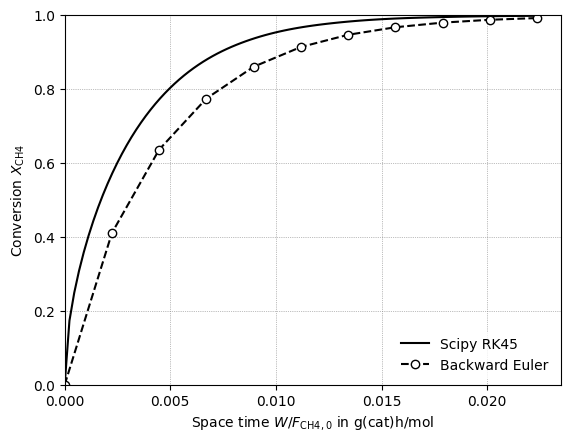

In [5]:
if True:
    import matplotlib.pyplot as plt

    fig = plt.figure()
    ax = fig.gca()

    ax.plot(
        sol_rk45.t / 3.6,
        sol_rk45.y[0],
        color="k",
        linestyle="-",
        marker="none",
        mec="k",
        mfc="k",
        label="Scipy RK45",
    )
    ax.plot(
        sol_euler.t / 3.6,
        sol_euler.y[0],
        color="k",
        linestyle="--",
        marker="o",
        mec="k",
        mfc="white",
        label="Backward Euler",
    )

    _ = ax.set_xlabel(r"Space time $W/F_{\mathrm{CH4},0}$ in $\mathrm{g(cat) h / mol}$")
    _ = ax.set_ylabel(r"Conversion $X_{\mathrm{CH4}}$")
    _ = ax.legend()

    _ = ax.set_xlim(
        0,
    )
    _ = ax.set_ylim(0, 1)
    _ = ax.grid(True)

### Reformer feasibility problem
[back](#Table-of-contents)

In [6]:
from phdtools.optimization.pyomo import SteamReformingCompounds
from phdtools.optimization.pyomo._reformer_block import pyomo_create_model

In [7]:
thermalEfficiency = 0.80
steamToCarbonRatio = 2.0

molarFlowRateInSI = EPSILON * np.ones(len(Compound), dtype=np.float64)
molarFlowRateInSI[Compound["C1H4(g)"].value] = (
    thermalEfficiency ** (-1)
    * NOMINAL_THERMAL_POWER_SI
    / np.abs(GROSS_CALORIFIC_VALUE_METHANE_SI)
)
molarFlowRateInSI[Compound["H2O1(g)"].value] = (
    steamToCarbonRatio * molarFlowRateInSI[Compound["C1H4(g)"].value]
)

ns = "reformer_feasibility_problem"
data_dict = {
    ns: {
        "setCompounds": [c.name for c in SteamReformingCompounds],
        "molarFlowRateInSI": {
            c.name: molarFlowRateInSI[c.value] for c in SteamReformingCompounds
        },
    }
}

data_dict_reformer = create_reformer_data_dict(namespace="reformer")
data_dict[ns].update(data_dict_reformer)

In [8]:
model = pyomo_create_model()
instance = model.create_instance(
    data=data_dict, namespace="reformer_feasibility_problem"
)

In [9]:
instance.inlet_conditions.pprint()
# for k in instance.reformer.setCompounds:
#     print(k)

inlet_conditions : Size=5, Index=setCompounds, Active=True
    Key     : Lower               : Body                                  : Upper               : Active
    C1H4(g) : 0.01753168663016186 : reformer.molarFlowRateSI['C1H4(g)',0] : 0.01753168663016186 :   True
    C1O1(g) :               1e-08 : reformer.molarFlowRateSI['C1O1(g)',0] :               1e-08 :   True
    C1O2(g) :               1e-08 : reformer.molarFlowRateSI['C1O2(g)',0] :               1e-08 :   True
    H2(ref) :               1e-08 : reformer.molarFlowRateSI['H2(ref)',0] :               1e-08 :   True
    H2O1(g) : 0.03506337326032372 : reformer.molarFlowRateSI['H2O1(g)',0] : 0.03506337326032372 :   True


In [10]:
# for var in instance.reformer.component_objects(pyo.Var):
#     var.pprint()

### Solve reformer feasibility problem
[back](#Table-of-contents)

SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  AMPL/MP 4.0.4        AMPL .nl file reader

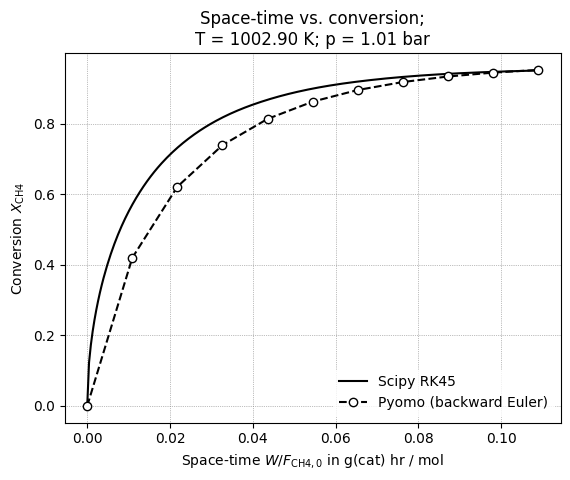

In [11]:
model = pyomo_create_model()
instance = model.create_instance(
    data=data_dict, namespace="reformer_feasibility_problem"
)

# instance.reformer.temperature.fix(.9)

with pyo.SolverFactory("scip") as opt:
    res = opt.solve(instance, tee=True)

_ = plot_optimization_result_space_time_reforming(block=instance.reformer)

In [12]:
# pyomo_print_constraint_residuals(instance.reformer)

In [13]:
model = pyomo_create_model()
instance = model.create_instance(
    data=data_dict, namespace="reformer_feasibility_problem"
)

# instance.reformer.temperature.fix(1.2)
if False:
    with pyo.SolverFactory("gurobi_direct_minlp") as opt:
        # opt.options["FeasibilityTol"] = 1e-4
        # opt.options["Presolve"] =  0
        res = opt.solve(instance, tee=True)

    _ = plot_optimization_result_space_time_reforming(block=instance.reformer)

### Warmstart reformer feasibility problem
[back](#Table-of-contents)

In [14]:
from phdtools.optimization.pyomo import warmstart_reformer
from phdtools.optimization import REFORMER_TEMPERATURE_SI_INIT

thermalEfficiency = 0.80
steamToCarbonRatio = 2.0

molarFlowRateInSI = EPSILON * np.ones(len(Compound), dtype=np.float64)
molarFlowRateInSI[Compound["C1H4(g)"].value] = (
    thermalEfficiency ** (-1)
    * NOMINAL_THERMAL_POWER_SI
    / np.abs(GROSS_CALORIFIC_VALUE_METHANE_SI)
)
molarFlowRateInSI[Compound["H2O1(g)"].value] = (
    steamToCarbonRatio * molarFlowRateInSI[Compound["C1H4(g)"].value]
)

warmstart_reformer(instance.reformer, REFORMER_TEMPERATURE_SI_INIT, molarFlowRateInSI)

# for v in instance.component_data_objects(pyo.Var):
#     assert v.value is not None

In [15]:
# pyomo_print_constraint_residuals(instance)

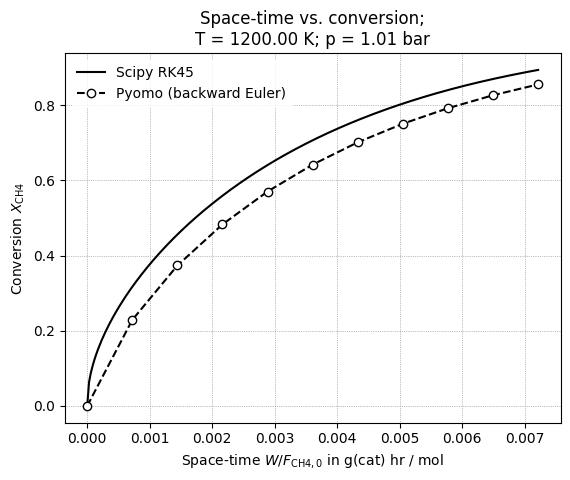

In [16]:
_ = plot_optimization_result_space_time_reforming(block=instance.reformer)

In [17]:
model = pyomo_create_model()
instance = model.create_instance(
    data=data_dict, namespace="reformer_feasibility_problem"
)

warmstart_reformer(instance.reformer, REFORMER_TEMPERATURE_SI_INIT, molarFlowRateInSI)

# instance.reformer.temperature.fix(1.2)

with pyo.SolverFactory("scip") as opt:
    res = opt.solve(instance, tee=True)

SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  AMPL/MP 4.0.4        AMPL .nl file reader

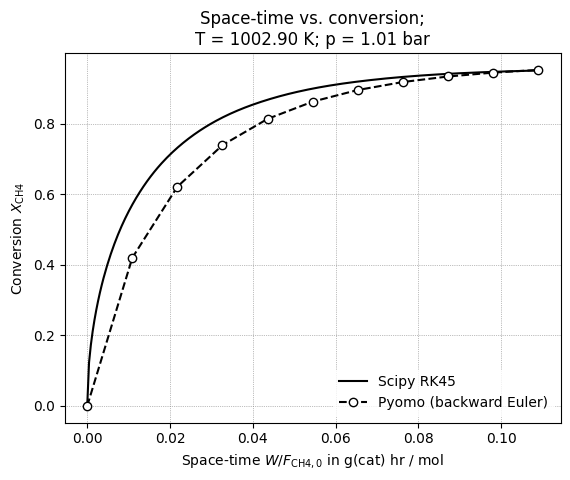

In [18]:
_ = plot_optimization_result_space_time_reforming(block=instance.reformer)

## Shift reactor
[back](#Table-of-contents)

In [19]:
from phdtools.models.mendes_2010 import (
    ModelParameters as WaterGasShiftParameters,
    Compound,
    initialValueProblemSpaceTime as shiftSpaceTimeIVP,
)
from phdtools.optimization import FUEL_CELL_CARBON_MONOXIDE_TOLERANCE
from phdtools.optimization.pyomo._shift_block import (
    NUM_FINITE_ELEMENTS,
    steamReformingCompounds,
)
from phdtools.optimization.pyomo._shift_warmstart import get_spaceTimeFromConversion

### Inlet conditions from reformer problem

In [20]:
def get_totalMolarFlowRateSI(block):
    return pyo.value(sum(block.molarFlowRateSI[:, block.setTimeSteps.last()]))


def get_moleFractionOut(block, k):
    return pyo.value(block.molarFlowRateSI[k, block.setTimeSteps.last()]) / (
        pyo.value(sum(block.molarFlowRateSI[:, block.setTimeSteps.last()]))
    )  # + pyo.value(sum(block.molarFlowRateInertCompoundsSI[j] for j in block.setInertCompounds)) )

In [21]:
totalMolarFlowRateInSI = (
    MOLAR_FLOW_RATE_METHANE_IN_SI + steamToCarbonRatio * MOLAR_FLOW_RATE_METHANE_IN_SI
)
totalMolarFlowRateInSI

np.float64(0.05259505989048559)

In [22]:
totalMolarFlowRateInSI = get_totalMolarFlowRateSI(instance.reformer)
totalMolarFlowRateInSI

0.09254656027687835

In [23]:
moleFractionIn = np.zeros(len(Compound))

for c in Compound:
    if c.name in instance.reformer.setReactingCompounds:
        moleFractionIn[c.value] = get_moleFractionOut(instance.reformer, c.name)
    # elif c.name in instance.reformer.setInertCompounds:
    #     moleFractionIn[c.value] = get_moleFractionOut(instance.reformer,c.name)
    else:
        moleFractionIn[c.value] = 0

moleFractionIn[Compound["N2(ref)"].value] = 1 - moleFractionIn.sum()

molarFlowRateInSI = totalMolarFlowRateInSI * moleFractionIn


ns = "shift_fesibility_problem"
data_dict[ns] = {
    "setCompounds": [c.name for c in steamReformingCompounds],
    "molarFlowRateInSI": {
        c.name: float(molarFlowRateInSI[c.value])
        for c in Compound
        if c.name in set(c.name for c in steamReformingCompounds)
    },
}

data_dict_shift = create_shift_data_dict(namespace="shift")
data_dict[ns].update(data_dict_shift)

### Shift reference solution

In [24]:
from phdtools.optimization import SHIFT_PRESSURE_SI, SHIFT_TEMPERATURE_SI_INIT
from phdtools.optimization.pyomo._shift_block import pyomo_create_model

In [25]:
ns = "shift_fesibility_problem"
if True:
    params = WaterGasShiftParameters.init(model="LH1")

    temperatureKelvin = SHIFT_TEMPERATURE_SI_INIT
    pressureBar = SHIFT_PRESSURE_SI

    molarFlowRateInSI = np.zeros(len(Compound))
    for c in Compound:
        if c.name in data_dict[ns]["setCompounds"]:
            molarFlowRateInSI[c.value] = data_dict[ns]["molarFlowRateInSI"][c.name]

    moleFractionIn = molarFlowRateInSI / molarFlowRateInSI.sum()

    conversion = (
        1
        - FUEL_CELL_CARBON_MONOXIDE_TOLERANCE
        * molarFlowRateInSI.sum(axis=0)
        / molarFlowRateInSI[Compound["C1O1(g)"].value]
    )

    t0 = 0
    tf = get_spaceTimeFromConversion(
        conversion,
        molarFlowRateIn=molarFlowRateInSI,
        temperatureKelvin=temperatureKelvin,
        pressureBar=pressureBar,
        params=params,
    )

    spaceTimeSI = np.linspace(t0, tf, 100)  # in kg(cat) s / mol

    sol_rk45 = solve_ivp(
        fun=shiftSpaceTimeIVP,
        t_span=[spaceTimeSI.min(), spaceTimeSI.max()],
        y0=[0],
        method="RK45",
        t_eval=spaceTimeSI,
        dense_output=False,
        events=None,
        vectorized=True,
        args=(moleFractionIn, temperatureKelvin, pressureBar, params),
    )

    sol_euler = euler(
        fun=shiftSpaceTimeIVP,
        t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
        y0=np.array([0]),
        method="backward",
        n=NUM_FINITE_ELEMENTS_SHIFT,
        maxiter=50,
        args=(moleFractionIn, temperatureKelvin, pressureBar, params),
    )

/Users/marvinmeck/test/phd-tools-dev/phdtools/models/mendes_2010.py:345: RuntimeWarning: divide by zero encountered in divide
  return np.array([-1 / r])
/Users/marvinmeck/test/phd-env/lib/python3.13/site-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: invalid value encountered in divide
  return norm(self._estimate_error(K, h) / scale)


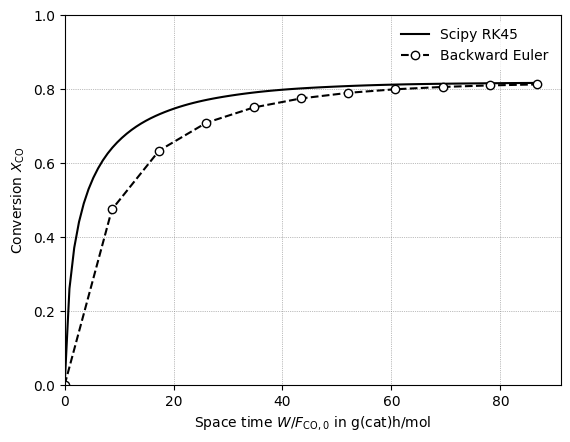

In [26]:
if True:
    import matplotlib.pyplot as plt

    fig = plt.figure()
    ax = fig.gca()

    ax.plot(
        sol_rk45.t / 3.6,
        sol_rk45.y[0],
        color="k",
        linestyle="-",
        marker="none",
        mec="k",
        mfc="k",
        label="Scipy RK45",
    )
    ax.plot(
        sol_euler.t / 3.6,
        sol_euler.y[0],
        color="k",
        linestyle="--",
        marker="o",
        mec="k",
        mfc="white",
        label="Backward Euler",
    )

    _ = ax.set_xlabel(r"Space time $W/F_{\mathrm{CO},0}$ in $\mathrm{g(cat) h / mol}$")
    _ = ax.set_ylabel(r"Conversion $X_{\mathrm{CO}}$")
    _ = ax.legend()

    _ = ax.set_xlim(
        0,
    )
    _ = ax.set_ylim(0, 1)
    _ = ax.grid(True)

### Shift feasibility problem
[back](#Table-of-contents)

In [27]:
model = pyomo_create_model()
instance = model.create_instance(data=data_dict, namespace="shift_fesibility_problem")

# instance.shift.temperature.fix(0.3)

with pyo.SolverFactory("scip") as opt:
    res = opt.solve(instance, tee=False)

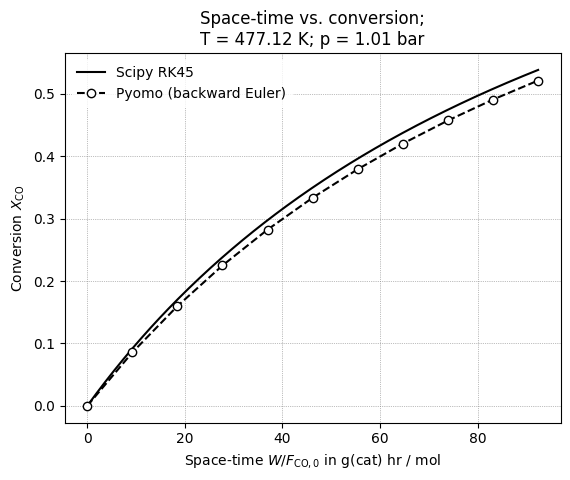

In [28]:
_ = plot_optimization_result_space_time_shift(block=instance.shift)

In [29]:
# instance.shift.pprint()

### Warmstart shift feasibility problem

In [30]:
from phdtools.optimization.pyomo import warmstart_shift

from phdtools.optimization import (
    SHIFT_TEMPERATURE_SI_INIT,
    FUEL_CELL_CARBON_MONOXIDE_TOLERANCE,
)

In [31]:
ns = "shift_fesibility_problem"
molarFlowRateInSI = np.zeros(len(Compound))
for c in Compound:
    if c.name in data_dict[ns]["setCompounds"]:
        molarFlowRateInSI[c.value] = data_dict[ns]["molarFlowRateInSI"][c.name]

warmstart_shift(instance.shift, SHIFT_TEMPERATURE_SI_INIT, molarFlowRateInSI)

WARNING (W1002): Setting Var 'shift.massCatalystScaled' to a numeric value
`5.236314425168986` outside the bounds (0.01, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',4]' to a
numeric value `1.0204245474760338` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',5]' to a
numeric value `1.0422640739520332` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',6]' to a
numeric value `1.0558118120900293` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',7]' to a
numeric value `1.0644533479468283` outside the bounds (1e-08, 1.0).
    See also https://

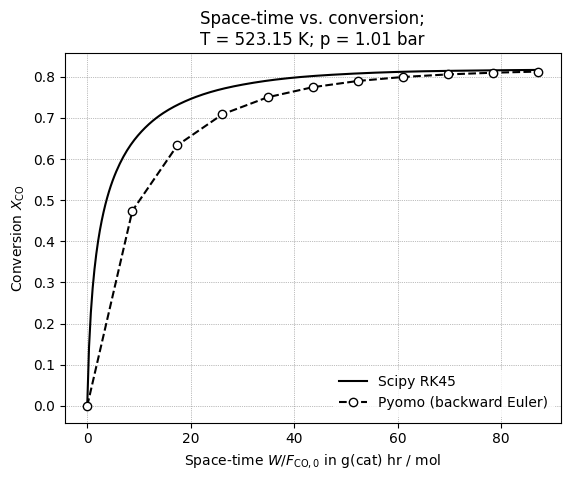

In [32]:
_ = plot_optimization_result_space_time_shift(block=instance.shift)

In [33]:
model = pyomo_create_model()
instance = model.create_instance(data=data_dict, namespace="shift_fesibility_problem")
warmstart_shift(instance.shift, SHIFT_TEMPERATURE_SI_INIT, molarFlowRateInSI)

# instance.shift.temperature.fix(0.3)

with pyo.SolverFactory("scip") as opt:
    res = opt.solve(instance, tee=True)

# with pyo.SolverFactory("gurobi_direct_minlp") as opt:
#     res = opt.solve(instance, tee=True)

WARNING (W1002): Setting Var 'shift.massCatalystScaled' to a numeric value
`5.236314425168986` outside the bounds (0.01, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',4]' to a
numeric value `1.0204245474760338` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',5]' to a
numeric value `1.0422640739520332` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',6]' to a
numeric value `1.0558118120900293` outside the bounds (1e-08, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'shift.molarFlowRateScaled['C1O2(g)',7]' to a
numeric value `1.0644533479468283` outside the bounds (1e-08, 1.0).
    See also https://

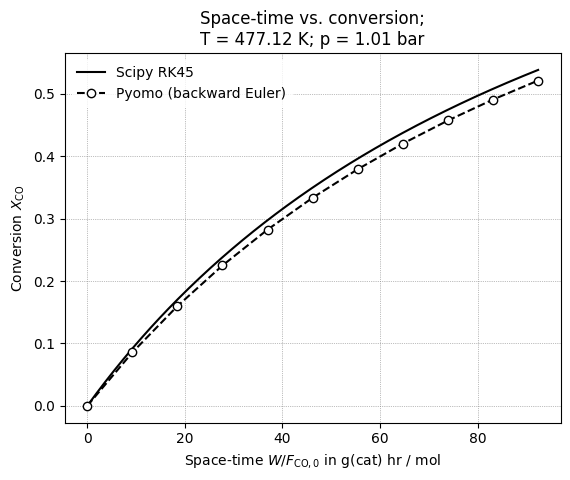

In [34]:
_ = plot_optimization_result_space_time_shift(block=instance.shift)

In [35]:
# pyomo_print_constraint_residuals(instance.shift)

## Fuel cell
[back](#Table-of-contents)

In [36]:
from phdtools.optimization.pyomo._fuel_cell_block import (
    pyomo_create_model,
    pyomo_print_result,
)

In [37]:
from scipy.optimize import root_scalar, minimize_scalar

from phdtools.optimization import (
    FUEL_CELL_TEMPERATURE_SI,
    FUEL_CELL_PRESSURE_SI,
    # FUEL_CELL_TOTAL_ACTIVE_AREA_UB,
)

from phdtools.models.meck_2025 import (
    ModelParameters as FuelCellParameters,
    get_fuelCellParameters,
    fuelCellVoltageModel,
)

params = get_fuelCellParameters(
    temperatureKelvin=FUEL_CELL_TEMPERATURE_SI, pressureBar=FUEL_CELL_PRESSURE_SI * 1e-5
)

params

ModelParameters(temperatureKelvin=393.15, reversibleCellPotentialSI=0.9269868578951337, exchangeCurrentDensityCathodeSI=18.837129452170522, transferCoefficientCathode=0.6597057, areaSpecificResistanceSI=1.8050870620749113e-05, limitingCurrentDensitySI=43100.12624672974)

In [38]:
# negativePowerDensity = lambda j: -1 * (j * fuelCellVoltageModel(j,params))
# currentDensityRange = np.linspace(EPSILON,2.7e4)
# powerDensityValues = negativePowerDensity(currentDensityRange)

# plt.plot(currentDensityRange,powerDensityValues)

In [39]:
ns = "fuel_cell_fesibility_problem"
data_dict[ns] = dict()
data_dict_fuel_cell = create_fuel_cell_data_dict(namespace="fuel_cell")
data_dict[ns].update(data_dict_fuel_cell)
# data_dict

/Users/marvinmeck/test/phd-tools-dev/phdtools/models/meck_2025.py:550: RuntimeWarning: divide by zero encountered in log
  + R * T / F * (1 / 4 + 1 / a) * np.log(1 - j / jL)


In [40]:
model = pyomo_create_model()
instance = model.create_instance(data_dict, namespace="fuel_cell_fesibility_problem")

with pyo.SolverFactory("scip") as opt:
    res = opt.solve(instance, tee=True)

SCIP version 10.0.1 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.1] [GitHash: 76a50c97d6]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  Readline 8.3         GNU library for command line editing (gnu.org/s/readline)
  SoPlex 8.0.1         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: c69290aa]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.2.12          General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.90.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  AMPL/MP 4.0.4        AMPL .nl file reader

In [41]:
pyomo_print_result(model=instance)

Current density (A/cm2):	0.69
Power density (W/cm2):		0.34
Cell potential (V):		0.49
Electrical efficiency:		0.33


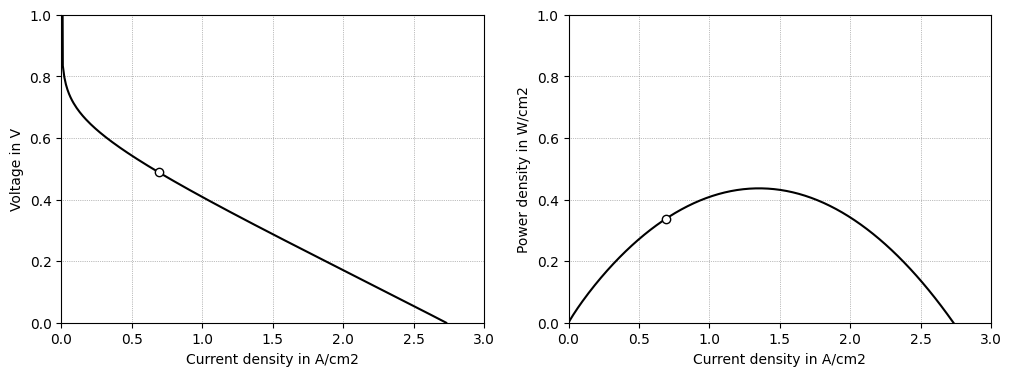

In [42]:
_ = plot_optimization_result_fuel_cell(instance.fuel_cell)